# Plot the Keeling Curve

data downloaded from : https://scrippsco2.ucsd.edu/data/primary-mauna-loa-co2-record/

I am using [Pandas](https://pandas.pydata.org/) to analyze the data. Pandas is excellent for tabular data (data with rows and columns).

I would suggeset getting a little familiar with Pandas. Corey Schafer on YouTube has some nice videos on this topic. See [here](https://www.youtube.com/watch?v=ZyhVh-qRZPA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# download the raw data
file = "https://keelinglabsites.ucsd.edu/websitedataco2/monthly_in_situ_co2_mlo.csv"
df = pd.read_csv(file, comment="\"")

# drop the first two rows, it is metadata I don't need
df = df.iloc[2:].reset_index(drop=True)

# remove spaces in column names
df.columns = df.columns.str.strip().str.replace(r"\s+", "_", regex=True)

# renme these because they are duplicates 
df.columns.values[8] = "CO2_filled"
df.columns.values[2] = "_value"

In [ ]:
# copy data
df_trim = df[["Date", "CO2"]].copy()

# make them into numbers (they are strings in the dataset)
df_trim["Date"] = pd.to_numeric(df_trim["Date"].astype(str).str.strip(), errors="coerce")
df_trim["CO2"] = pd.to_numeric(df_trim["CO2"].astype(str).str.strip(), errors="coerce").replace(-99.99, np.nan)

Text(0, 0.5, 'CO$_2$ concentration (ppm)')

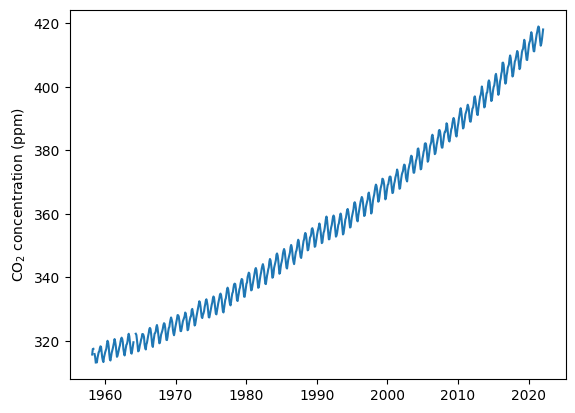

In [ ]:
# basic plot of keeling curve
plt.plot(df_trim["Date"], df_trim["CO2"])
plt.ylabel("CO$_2$ concentration (ppm)")
plt.title("Keeling Curve")